In [10]:
from matplotlib import pyplot as plt
import numpy as np


def plot_sonogram(addresses, timestamps, ax=None):
    addresses = np.asarray(addresses, dtype=np.int64)
    timestamps = np.copy(timestamps) / 10**8  # Convert timestamps to seconds

    # ---- time normalization ----
    t_min = np.min(timestamps)
    t = timestamps - t_min

    # ---- fixed resolution (important for performance stability) ----
    n_bins = 500
    max_timestamp = np.max(timestamps)
    duration = max_timestamp - t_min
    bin_size = duration / n_bins if duration > 0 else 1.0
    inv_bin = 1.0 / bin_size

    # ---- binning (vectorized) ----
    bin_idx = np.minimum((t * inv_bin).astype(np.int64), n_bins - 1)
    bin_start_times = t_min + np.arange(n_bins) * bin_size

    # ---- number of channels ----
    n_addr = int(np.max(addresses)) + 1

    # ---- FASTEST PATH: bincount flattening ----
    flat_idx = addresses * n_bins + bin_idx
    sonogram = np.bincount(
        flat_idx,
        minlength=n_addr * n_bins
    ).reshape(n_addr, n_bins)

    # ---- plot (but DO NOT show) ----
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    im = ax.imshow(
        sonogram,
        aspect="auto",
        origin="lower",
        cmap="hot",
        extent=[
        bin_start_times[0],
        bin_start_times[-1] + bin_size,
        0,
        n_addr - 1]
    )

    ax.set_ylabel("Address")
    ax.set_title("Spectogram")

    plt.colorbar(im, ax=ax)
    return fig, ax, im

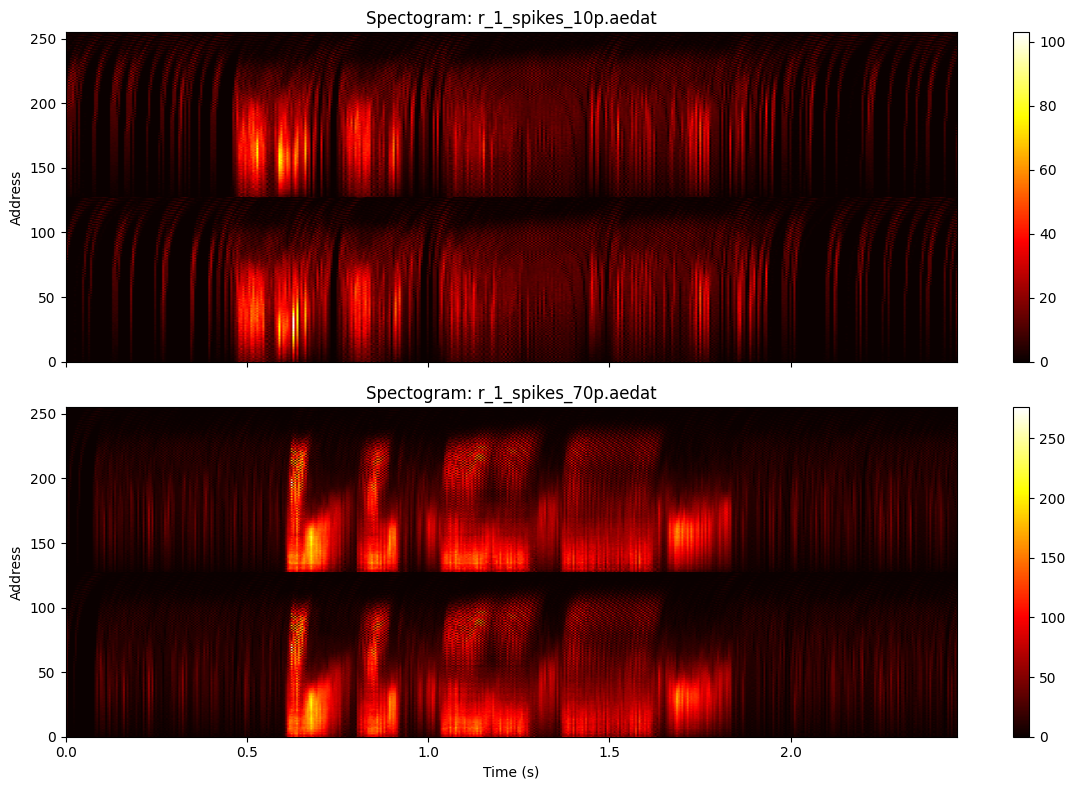

In [13]:
import tkinter as tk
from tkinter import filedialog

import AERzip

# Loading two compressed files (filedialog set on top of the main window)
root = tk.Tk()
root.withdraw()  # Hide the main window
root.attributes('-topmost', True)
file_1_path = filedialog.askopenfilename(title="Select a compressed aedat file", filetypes=[("Compressed aedat files", "*.aedat")])
file_2_path = filedialog.askopenfilename(title="Select another compressed aedat file", filetypes=[("Compressed aedat files", "*.aedat")])
root.destroy()

file_1_addresses, file_1_timestamps = AERzip.loadCompressedFile(file_1_path)
file_2_addresses, file_2_timestamps = AERzip.loadCompressedFile(file_2_path)

# Plot the sonograms stacked vertically with a shared X-axis for direct comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

plot_sonogram(file_1_addresses, file_1_timestamps, ax=axes[0])
axes[0].set_title("Spectogram: " + file_1_path.split("/")[-1])  # Set the name of the file as the title of the first subplot

plot_sonogram(file_2_addresses, file_2_timestamps, ax=axes[1])
axes[1].set_title("Spectogram: " + file_2_path.split("/")[-1])  # Set the name of the file as the title of the second subplot
axes[1].set_xlabel("Time (s)")

fig.tight_layout()
plt.show(fig)